In [87]:
import cv2
import numpy as np
import mediapipe as mp
import torch
import pandas as pd
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder

mp_pose = mp.solutions.pose
mp_hands = mp.solutions.hands

pose = mp_pose.Pose(
    static_image_mode=False,
    model_complexity=1
)

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1
)


def seed_everything(seed=42):
    # Python
    # random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch (CPU + MPS)
    torch.manual_seed(seed)

seed_everything(42)

I0000 00:00:1777474409.858508       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
I0000 00:00:1777474409.881837       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1


In [ ]:
# quick and easy way to see if theres motion by checking abs diff of pixels between prev and curr frame
def get_frames_motion_scores(video_path):
    cap = cv2.VideoCapture(video_path)

    prev = None
    scores = []
    frames = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (64, 64))  # not ccrop, still same image

        if prev is None:
            scores.append(0)
        else:
            diff = cv2.absdiff(prev, gray) # 2d 
            scores.append(np.mean(diff)) # could use linal.norm for better scores, mean kinda weak

        prev = gray
        frames.append(frame)

    cap.release()
    return frames, np.array(scores)

ex_path = "../data/clips/0/1.MOV"
frames, scores = get_frames_motion_scores(ex_path)
print(scores)


In [ ]:
# we choose what indices/frames by both motion scores and uniform sampling
# so 50/50 split between motion indices and uniform saimpling indices

def select_indices(scores, num_frames=32):
    T = len(scores)

    # if vid has fewer frames needed, then just return all frames/indices
    if T <= num_frames:
        return np.arange(T)

    k_motion = num_frames // 2
    motion_idx = np.argsort(scores)[-k_motion:] # sorts indices by motion scores, then gets k highest scores

    k_uniform = num_frames - k_motion
    uniform_idx = np.linspace(0, T - 1, k_uniform).astype(int)

    #combine
    indices = np.concatenate([motion_idx, uniform_idx])
    indices = np.unique(indices)

    # since removed uniques, padd with random indices
    if len(indices) < num_frames:
        extra = np.random.choice(T, num_frames - len(indices), replace=False)
        indices = np.concatenate([indices, extra])

    return np.sort(indices)

print(select_indices(scores))

[  0  16  32  48  64  81  97 113 120 129 145 162 178 182 183 184 185 186
 187 188 189 190 191 192 193 194 210 226 228 232 234 243]


In [ ]:
# feature extraction, normalization, flattening 

def extract_features(frame):
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # --- Pose ---
    pose_results = pose.process(image)

    if pose_results.pose_landmarks:
        
        pose_feats = torch.tensor([
            [lm.x, lm.y, lm.z, lm.visibility]
            for lm in pose_results.pose_landmarks.landmark
        ], dtype=torch.float32)
    else:
        pose_feats = torch.zeros((33, 4), dtype=torch.float32)

    # --- Hands ---
    hand_results = hands.process(image)

    left_hand = torch.zeros((21, 3), dtype=torch.float32)
    right_hand = torch.zeros((21, 3), dtype=torch.float32)

    if hand_results.multi_hand_landmarks and hand_results.multi_handedness:
        for landmarks, handedness in zip(
            hand_results.multi_hand_landmarks,
            hand_results.multi_handedness
        ):
            coords = torch.tensor(
                [[lm.x, lm.y, lm.z] for lm in landmarks.landmark],
                dtype=torch.float32
            )

            label = handedness.classification[0].label

            if label == "Left":
                left_hand = coords
            else:
                right_hand = coords

    return {
        "pose": pose_feats,
        "left": left_hand,
        "right": right_hand
    }

feats = extract_features(frames[0])
print(feats['pose'])

# normalize the pose and hand features by centering on the shoulders and scaling by shoulder distance, also center hand features on wrists

def normalize_features(feats):
    pose = feats["pose"]
    left = feats["left"]
    right = feats["right"]

   # pose
    coords = pose[:, :3]
    vis = pose[:, 3:]

    left_shoulder = coords[11]
    right_shoulder = coords[12]

    center = (left_shoulder + right_shoulder) / 2
    coords = coords - center

    scale = torch.norm(left_shoulder - right_shoulder)
    if scale > 0:
        coords = coords / scale

    pose = torch.cat([coords, vis], dim=1)

    # hands
    left_wrist = coords[15]
    right_wrist = coords[16]

    if torch.any(left != 0):
        left = left - left_wrist

    if torch.any(right != 0):
        right = right - right_wrist

    return {
        "pose": pose,
        "left": left,
        "right": right
    }

def flatten_features(feats):
    return torch.cat([
        feats["pose"].flatten(),
        feats["left"].flatten(),
        feats["right"].flatten()
    ])

In [ ]:


def vid_to_tensor(vid_path, num_frames=32):
    frames, scores = get_frames_motion_scores(vid_path)
    indices = select_indices(scores, num_frames)

    selected_frames = [frames[i] for i in indices]

    sequence = []
    for frame in selected_frames:
        landmarks = extract_features(frame)
        landmarks = normalize_features(landmarks) # normalize and flatten in separate steps for better readability, could combine if wanted
        landmarks = flatten_features(landmarks)

        if landmarks is None:
            if len(sequence) > 0:
                landmarks = sequence[-1] # choose prev if extraction failed
            else:
                continue

        sequence.append(landmarks)

    sequence = np.array(sequence)

    # pad if needed
    if len(sequence) < num_frames:
        pad = np.repeat(sequence[-1][None, :], num_frames - len(sequence), axis=0)
        sequence = np.vstack([sequence, pad])

    # normalize each seq
    mean = sequence.mean(axis=0)
    std = sequence.std(axis=0) + 1e-6
    sequence = (sequence - mean) / std

    return torch.tensor(sequence, dtype=torch.float32) # shape = (frames, features)

ex_path = '../data/clips/0/0.MOV'
vid_to_tensor(ex_path).shape

In [92]:
# noise variation

def temporal_jitter(seq, max_shift=2):
    shift = torch.randint(-max_shift, max_shift + 1, (1,)).item()

    if shift > 0:
        seq = torch.cat([
            seq[shift:], 
            seq[-1:].repeat(shift, 1)
        ], dim=0)

    elif shift < 0:
        shift = abs(shift)
        seq = torch.cat([
            seq[:1].repeat(shift, 1), 
            seq[:-shift]
        ], dim=0)

    return seq

def frame_dropout(seq, p=0.1):
    mask = torch.rand(seq.shape[0]) > p
    return seq[mask]

def add_landmark_noise(seq, sigma=0.01):
    return seq + torch.randn_like(seq) * sigma


def augment_sequence(seq):
    if torch.rand(1) < 0.7:
        seq = temporal_jitter(seq)

    if torch.rand(1) < 0.5:
        seq = add_landmark_noise(seq)

    # if torch.rand(1) < 0.3:
    #     seq = frame_dropout(seq)

    # seq = temporal_resample(seq, 32)

    return seq

aug_seq = augment_sequence(vid_to_tensor(ex_path))
print(aug_seq.shape)

torch.Size([32, 258])


In [110]:

# create a dataset for the loader (bascailly dis is for lazy loading, no need to load the whole dataset into mem)

class SignLanguageDataset(Dataset):
    def __init__(self, df, label_encoder=None):
        self.df = df.reset_index(drop=True)

        self.cache = {}
        
        # Encode labels
        if label_encoder is None:
            self.le = LabelEncoder()
            self.labels = self.le.fit_transform(df["label"])
        else:
            self.le = label_encoder
            self.labels = self.le.transform(df["label"])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        vid_path = self.df.loc[idx, "vid_path"]
        
        if vid_path in self.cache:
            x = self.cache[vid_path]
        else:
            x = vid_to_tensor(vid_path,48)
            x = augment_sequence(x)
            self.cache[vid_path] = x 

        y = torch.tensor(self.labels[idx], dtype=torch.long)

        return x, y

In [111]:
# data loader 
from torch.utils.data import DataLoader

df = pd.read_csv("../data/train.csv")
df["vid_path"] = df["vid_path"].str.replace("\\\\", "/", regex=True) # posix complaint (ie make it work on mac fix)
df["vid_path"] = '../data/' + df['vid_path']

filtered = df[df['category'].str.contains('SURVIVAL', na=False)]
filtered = filtered[~filtered['label'].str.contains('NO|YES|SLOW|FAST', na=False)]
print(filtered.shape)
print(filtered['label'].unique())
    

df2 = pd.read_csv("../data/test.csv")
df2["vid_path"] = df2["vid_path"].str.replace("\\\\", "/", regex=True) # posix complaint (ie make it work on mac fix)
df2["vid_path"] = '../data/' + df2['vid_path']

filtered_test = df2[df2['category'].str.contains('SURVIVAL', na=False)]
filtered_test = filtered_test[~filtered_test['label'].str.contains('NO|YES|SLOW|FAST', na=False)]
print(filtered_test.shape)
print(filtered_test['label'].unique())

dataset = SignLanguageDataset(filtered)
dataset_test = SignLanguageDataset(filtered_test, label_encoder=dataset.le)

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
)

test_loader = DataLoader(
    dataset_test,
    batch_size=16,
    shuffle=False,
)



(67, 4)
<StringArray>
['CORRECT', 'UNDERSTAND', 'WRONG', 'DON’T UNDERSTAND']
Length: 4, dtype: str
(17, 4)
<StringArray>
['CORRECT', 'DON’T UNDERSTAND', 'WRONG', 'UNDERSTAND']
Length: 4, dtype: str


In [112]:
# define and init model

import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, num_classes):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # bidirectional doubles hidden_dim
        self.norm = nn.LayerNorm(hidden_dim * 2)

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)          # (B, T, 2*hidden_dim)

        out = out.mean(dim=1)         # better than last timestep

        out = self.norm(out)
        out = self.dropout(out)

        out = self.fc(out)
        return out

input_dim = 258 # features
hidden_dim = 64
num_layers = 1
num_classes = len(filtered['label'].unique()) # labels
print(num_classes)
model = LSTMModel(input_dim, hidden_dim, num_layers, num_classes)

4


In [113]:
def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


In [114]:
# train model

import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 10

train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X, y in train_loader:
        outputs = model(X)
        loss = criterion(outputs, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    val_acc = evaluate_accuracy(model, test_loader)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Acc={val_acc:.4f}")

Epoch 1: Loss=0.9741, Val Acc=0.8824
Epoch 2: Loss=0.4031, Val Acc=0.8235
Epoch 3: Loss=0.3024, Val Acc=0.8824
Epoch 4: Loss=0.2111, Val Acc=0.9412
Epoch 5: Loss=0.1509, Val Acc=0.9412
Epoch 6: Loss=0.1183, Val Acc=0.9412
Epoch 7: Loss=0.0873, Val Acc=0.9412
Epoch 8: Loss=0.0763, Val Acc=0.9412
Epoch 9: Loss=0.0399, Val Acc=0.9412
Epoch 10: Loss=0.0547, Val Acc=0.9412


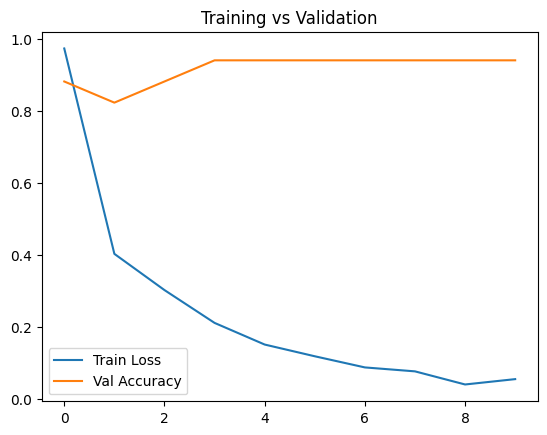

In [115]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Training vs Validation")
plt.show()

In [116]:
torch.save({
    "epoch": epoch,
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "loss": loss,
}, "with_norm_noise_48frames.pth")

In [117]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)

        all_preds.append(preds)
        all_labels.append(y)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

accuracy = (all_preds == all_labels).float().mean()
print("Test Accuracy:", accuracy.item())

Test Accuracy: 0.9411764740943909


In [105]:
def get_predictions(model, loader):
    model.eval()
    
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X, y in test_loader:
            outputs = model(X)
            preds = torch.argmax(outputs, dim=1)

            all_preds.append(preds)
            all_labels.append(y)

    all_preds = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()

    return all_preds, all_labels

In [118]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

preds, labels = get_predictions(model, loader)

cm = confusion_matrix(labels, preds)

[[5 0 0 0]
 [0 4 0 0]
 [0 0 4 0]
 [0 0 1 3]]


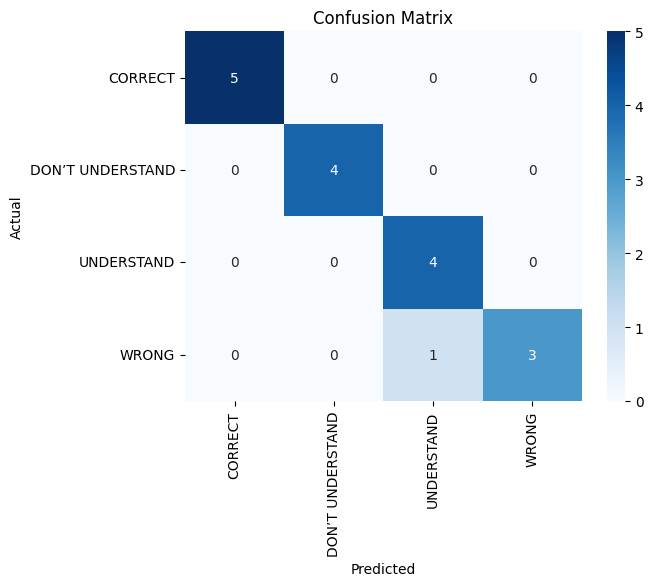

In [119]:
import seaborn as sns

class_names = dataset.le.classes_  # adjust to your labels

print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [120]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds, target_names=class_names))

                  precision    recall  f1-score   support

         CORRECT       1.00      1.00      1.00         5
DON’T UNDERSTAND       1.00      1.00      1.00         4
      UNDERSTAND       0.80      1.00      0.89         4
           WRONG       1.00      0.75      0.86         4

        accuracy                           0.94        17
       macro avg       0.95      0.94      0.94        17
    weighted avg       0.95      0.94      0.94        17



In [ ]:
# testing with user input vids, not from dataset, just to see if it works on random vids and showing confidence scores
import torch.nn.functional as F

model = LSTMModel(input_dim, hidden_dim, num_layers, num_classes)
optimizer = torch.optim.Adam(model.parameters())  # same optimizer type
checkpoint = torch.load("with_norm_noise_48frames.pth", map_location="cpu")
model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

model.eval()

sequence = []
sequence_length = 32

# place ur own vids/vidpaths here
vid_paths = ['../understand_best.MOV', '../understand_shift_left.MOV']


for vid_path in vid_paths:
    X = vid_to_tensor(vid_path, num_frames=50).unsqueeze(0)



    with torch.no_grad():
        output = model(X)                 # logits
        probs = F.softmax(output, dim=1)  # convert to probabilities
        
        confidence, pred = torch.max(probs, dim=1)

    label = dataset.le.classes_[pred.item()]

    print(vid_path)
    print("Predicted label:", label)
    print("Confidence:", confidence.item())




../understand_best.MOV
Predicted label: UNDERSTAND
Confidence: 0.900468111038208
../understand_shift_left.MOV
Predicted label: UNDERSTAND
Confidence: 0.8874875903129578
